# Analyse Exploratoire

## Import des modules

In [636]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from scipy import stats

In [637]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



## Analyse Exploratoire

### Visualisation du dataset

In [638]:
building_consumption = pd.read_csv('./2016_Building_Energy_Benchmarking.csv')

In [639]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [640]:
building_consumption.shape

(3376, 46)

### Consignes

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Quelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

### Suppression des données qui ne concerne pas le projet

In [641]:
# REVOIR SI ON ENLEVE OU NON LES 'NON COMPLIANT DATAS'
#building_consumption['ComplianceStatus'].unique()

In [642]:
BuildingType_To_Keep = [
    'NonResidential',
    'Nonresidential COS',
    'SPS-District K-12',
    'Campus',
    'Nonresidential WA'
]
# compliance_To_Keep =[
#     'Compliant',
#     'Missing Data']


NR_building_consumption = building_consumption.loc[building_consumption['BuildingType'].isin(BuildingType_To_Keep)]
#NR_building_WO_outliers_consumption = NR_building_consumption[building_consumption['ComplianceStatus'].isin(compliance_To_Keep)]
NR_building_consumption.shape


(1668, 46)

### Traitement outliers par quartile

In [643]:
def quantile_outliers(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)

    iqr = q3 - q1

    low_limite = q1 - 1.5 *iqr
    high_limite = q3 + 1.5 * iqr
    return [low_limite,high_limite]

In [644]:
outlier_columns = ['GHGEmissionsIntensity','TotalGHGEmissions','PropertyGFABuilding(s)']
TempQuartOutliers = NR_building_consumption
for column in outlier_columns:
    limite_basse, limite_haute = quantile_outliers(TempQuartOutliers[column])
    TempQuartOutliers = TempQuartOutliers[(TempQuartOutliers[column]>limite_basse) & (TempQuartOutliers[column]<limite_haute)]
    print(TempQuartOutliers.shape)

(1526, 46)
(1355, 46)
(1230, 46)


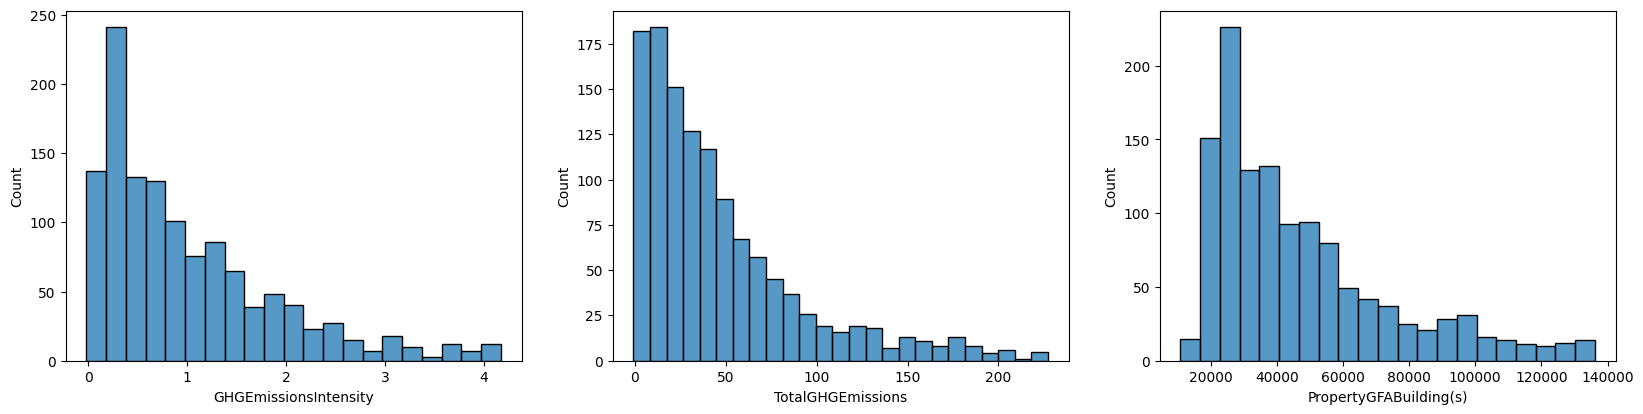

In [645]:
plt.figure(figsize=(20,10))
for i,column in enumerate(outlier_columns):
    plt.subplot(int(len(outlier_columns)/3)+1,3,i+1)
    sns.histplot(data=TempQuartOutliers[column])


In [646]:
NR_building_WO_outliers_consumption = TempQuartOutliers

### Suppression des colonnes inutiles

In [647]:
columns_to_drop = ['TaxParcelIdentificationNumber','ZipCode',
                   'Address','PropertyName','DataYear','City','State','Outlier',
                    'ComplianceStatus' , 'Comments' , 'NaturalGas(therms)' ,'DefaultData',
                    'Electricity(kWh)' ,'SourceEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)','YearsENERGYSTARCertified']

NR_building_WO_outliers_consumption.drop(columns_to_drop, axis=1, inplace=True)
NR_building_WO_outliers_consumption.shape

(1230, 30)

- 'TaxParcelIdentificationNumber','ZipCode','Address','PropertyName','DataYear','City','State','Outlier', 'ComplianceStatus' , 'Comments' ,'DefaultData' = valeur constante ou ne servent à rien  
- 'NaturalGas(therms)' , 'Electricity(kWh)' = Doublon avec la valeur en kBtu  
- 'SourceEUIWN(kBtu/sf)','SourceEUI(kBtu/sf)' = doublon avec les siteEnergyuse  
- 'YearsENERGYSTARCertified' = trop de Na  


### Suppression de la valeur NA dans site EUIW

In [648]:
NR_building_WO_outliers_consumption= NR_building_WO_outliers_consumption[NR_building_WO_outliers_consumption['SiteEUIWN(kBtu/sf)'].notna()]
NR_building_WO_outliers_consumption.shape

(1229, 30)

**Décision :** Variable cible = **TotalGHGEmissions**

### Prouver la relation entre les energies et le CO²

(0.0, 7000000.0)

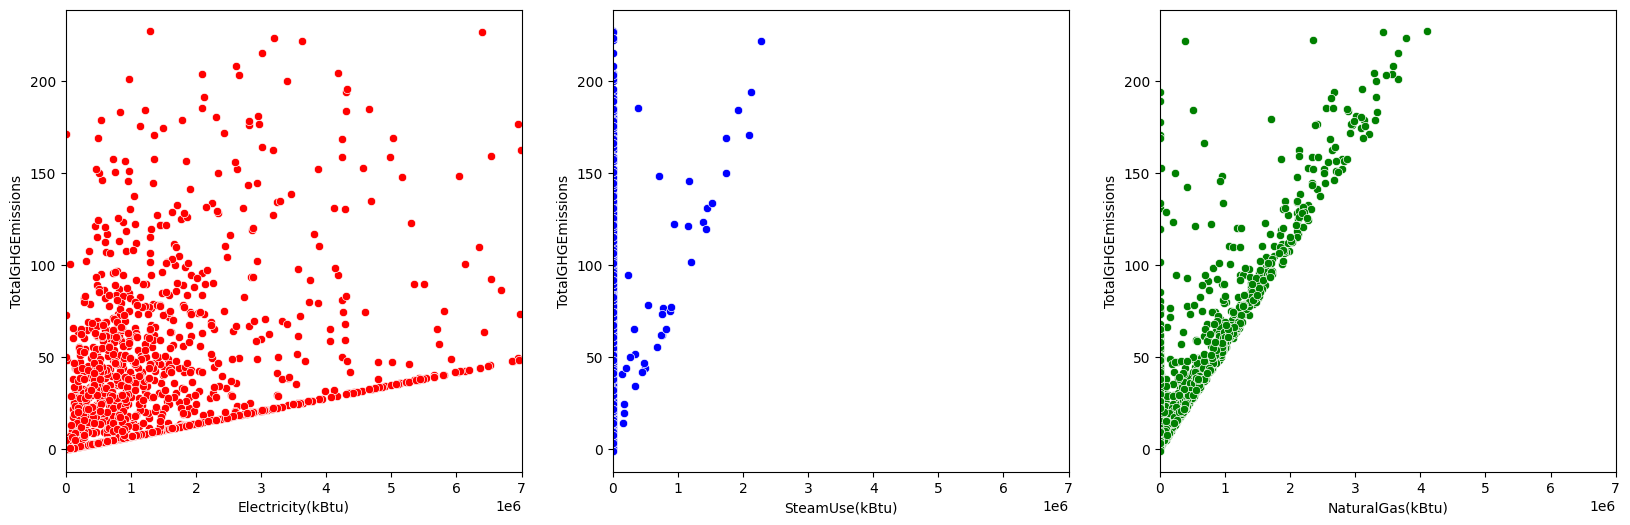

In [649]:
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
sns.scatterplot(data=NR_building_WO_outliers_consumption, x='Electricity(kBtu)', y='TotalGHGEmissions', c='red')
plt.xlim(0,7000000)
plt.subplot(1,3,2)
sns.scatterplot(data=NR_building_WO_outliers_consumption, x='SteamUse(kBtu)', y='TotalGHGEmissions', c ='blue')
plt.xlim(0,7000000)
plt.subplot(1,3,3)
sns.scatterplot(data=NR_building_WO_outliers_consumption, x='NaturalGas(kBtu)', y='TotalGHGEmissions', c ='green')
plt.xlim(0,7000000)

**Conclusion :** Il y a une forte corrélation entre la consommation des énergies et le CO²  
On peut aussi deviner que la vapeur emet plus que le gaz qui lui même emet plus que l'electricité 

In [650]:
NR_building_WO_outliers_consumption.isna().sum()

OSEBuildingID                         0
BuildingType                          0
PrimaryPropertyType                   0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     0
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             0
LargestPropertyUseType                4
LargestPropertyUseTypeGFA             4
SecondLargestPropertyUseType        650
SecondLargestPropertyUseTypeGFA     650
ThirdLargestPropertyUseType        1014
ThirdLargestPropertyUseTypeGFA     1014
ENERGYSTARScore                     426
SiteEUI(kBtu/sf)                      0
SiteEUIWN(kBtu/sf)                    0
SiteEnergyUse(kBtu)                   0
SiteEnergyUseWN(kBtu)                 0


### Prouver la relation entre type de propriété et ENERGYSTAR

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'Hotel'),
  Text(1, 0, 'Other'),
  Text(2, 0, 'K-12 School'),
  Text(3, 0, 'Small- and Mid-Sized Office'),
  Text(4, 0, 'Self-Storage Facility'),
  Text(5, 0, 'Retail Store'),
  Text(6, 0, 'University'),
  Text(7, 0, 'Residence Hall'),
  Text(8, 0, 'Warehouse'),
  Text(9, 0, 'Mixed Use Property'),
  Text(10, 0, 'Senior Care Community'),
  Text(11, 0, 'Worship Facility'),
  Text(12, 0, 'Large Office'),
  Text(13, 0, 'Distribution Center'),
  Text(14, 0, 'Medical Office'),
  Text(15, 0, 'Supermarket / Grocery Store'),
  Text(16, 0, 'Refrigerated Warehouse'),
  Text(17, 0, 'Low-Rise Multifamily'),
  Text(18, 0, 'Restaurant'),
  Text(19, 0, 'Laboratory'),
  Text(20, 0, 'Hospital'),
  Text(21, 0, 'Office')])

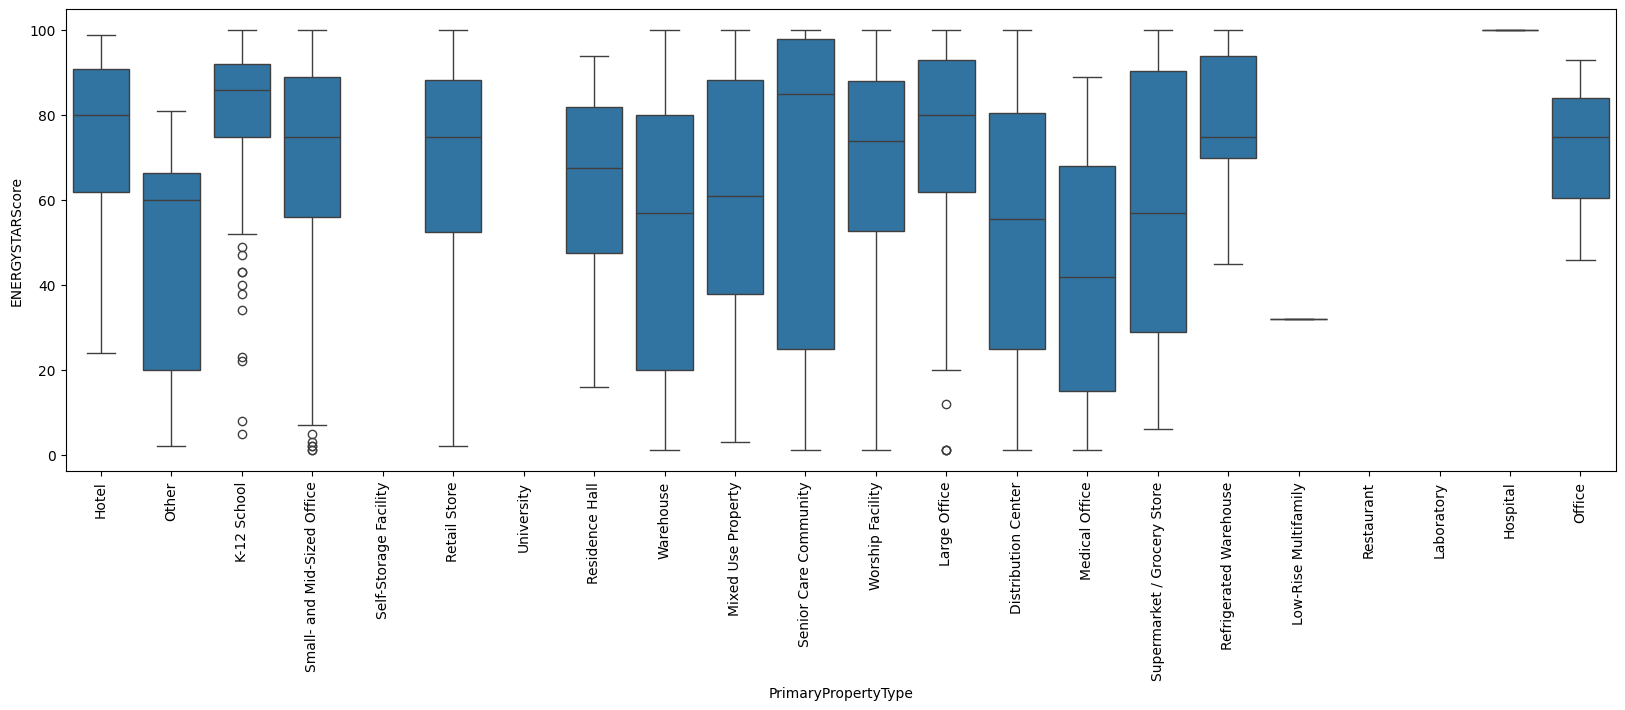

In [651]:
plt.figure(figsize=(20,6))
sns.boxplot(data= NR_building_WO_outliers_consumption, x='PrimaryPropertyType', y='ENERGYSTARScore')
plt.xticks(rotation=90)

### Nettoyage des varaible de 'NEIGHBORHOOD

In [652]:
# ['DOWNTOWN', 'NORTHEAST', 'Central', 'MAGNOLIA / QUEEN ANNE',
#        'BALLARD', 'GREATER DUWAMISH', 'LAKE UNION', 'CENTRAL',
#        'SOUTHWEST', 'DELRIDGE', 'EAST', 'SOUTHEAST', 'NORTHWEST', 'NORTH',
#        'North', 'Delridge', 'Ballard', 'Northwest',
#        'DELRIDGE NEIGHBORHOODS']
NR_building_WO_outliers_consumption['Neighborhood'] = NR_building_WO_outliers_consumption['Neighborhood'].str.upper()
NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['Neighborhood']=='DELRIDGE NEIGHBORHOODS','Neighborhood'] = 'DELRIDGE'
NR_building_WO_outliers_consumption['Neighborhood'].unique()

C:\Users\Fabien\AppData\Local\Temp\ipykernel_1328\716023056.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consumption['Neighborhood'] = NR_building_WO_outliers_consumption['Neighborhood'].str.upper()


array(['DOWNTOWN', 'SOUTHEAST', 'NORTHEAST', 'CENTRAL',
       'MAGNOLIA / QUEEN ANNE', 'LAKE UNION', 'BALLARD',
       'GREATER DUWAMISH', 'EAST', 'SOUTHWEST', 'DELRIDGE', 'NORTHWEST',
       'NORTH'], dtype=object)

### Classification de l'ENERGYSTAR pour combler les NA

(1175, 30)
(1104, 30)
(726, 11)
TotalGHGEmissions | skew = -0.019451667179338317 | kurt = -0.31001237178520213 | Statistique = 0.9957558047310308 | p-value = 0.04509898878744083
SiteEUI(kBtu/sf) | skew = -0.02936019418840873 | kurt = -0.018945174366973738 | Statistique = 0.9970710435767752 | p-value = 0.21533583218571511
SiteEUIWN(kBtu/sf) | skew = -0.06867016249808972 | kurt = 0.041673988724487465 | Statistique = 0.9962015263195946 | p-value = 0.07733328215749308


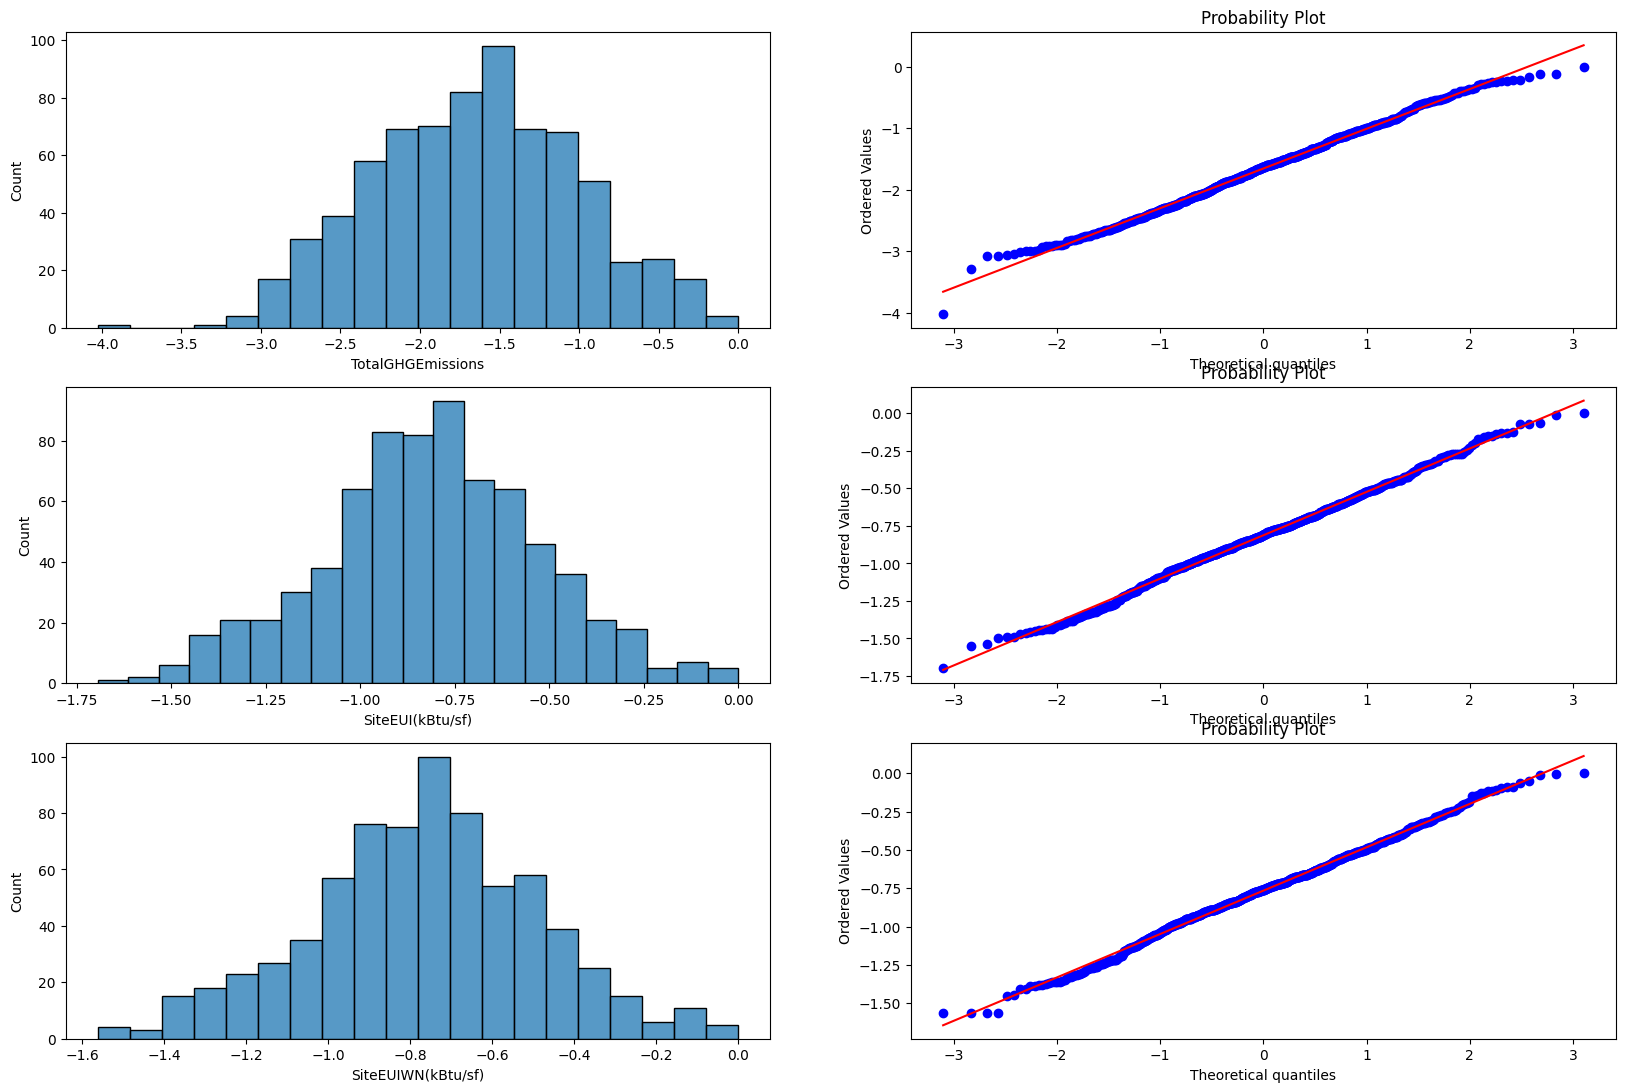

In [653]:
df = NR_building_WO_outliers_consumption

nrj_outlier_columns = ['SiteEUI(kBtu/sf)','SiteEnergyUse(kBtu)']

for column in nrj_outlier_columns:
    limite_basse, limite_haute = quantile_outliers(df[column])
    df = df[(df[column]>limite_basse) & (df[column]<limite_haute)]
    print(df.shape)

# Sélection des variables de base
X_nrj = df.loc[df['ENERGYSTARScore'].notna(),
    ['SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
     'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'PrimaryPropertyType', 'YearBuilt',
     'PropertyGFABuilding(s)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'TotalGHGEmissions',
     'GHGEmissionsIntensity']]
print(X_nrj.shape)

columns_to_normalize = ['TotalGHGEmissions' , 'SiteEUI(kBtu/sf)' , 'SiteEUIWN(kBtu/sf)'] #,'PropertyGFABuilding(s)'

from sklearn.preprocessing import PowerTransformer
from scipy.stats import shapiro

STDscaler = MinMaxScaler()

for column in X_nrj[columns_to_normalize] :
    X_nrj[column] = STDscaler.fit_transform(X_nrj[[column]])
    X_nrj.loc[X_nrj[column]==0,column] = 0.0001
    


plt.figure(figsize=(20,50))
for i, colonne in enumerate(columns_to_normalize):
    X_nrj[colonne], coef = stats.boxcox(X_nrj[colonne]) #TotalGHGEmissions , SiteEUI(kBtu/sf) , SiteEUIWN(kBtu/sf)

    plt.subplot(X_nrj.shape[1],2,i*2+1)
    sns.histplot(X_nrj, x=colonne)
    plt.subplot(X_nrj.shape[1],2,i*2+2)
    stats.probplot(X_nrj[colonne], plot=plt)

    stat, p = shapiro(X_nrj[colonne])
    print(f'{colonne} | skew = {X_nrj[colonne].skew()} | kurt = {X_nrj[colonne].kurtosis()} | Statistique = {stat} | p-value = {p}')



In [654]:
y_nrj = df.loc[df['ENERGYSTARScore'].notna(),'ENERGYSTARScore']

# Encodage OneHot de la variable catégorielle
PrimaryPropertyType_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
df_encoded = PrimaryPropertyType_encoder.fit_transform(X_nrj[['PrimaryPropertyType']])
X_nrj = pd.concat([X_nrj.drop('PrimaryPropertyType', axis=1), df_encoded.astype(bool)], axis=1)

#
# Split train/test
X_nrj_train, X_nrj_test, y_nrj_train, y_nrj_test = train_test_split(X_nrj, y_nrj, test_size=0.2, random_state=42)
colonnes_entraînement = X_nrj_train.columns.tolist()

# Normalisation
# MM_scaler = MinMaxScaler()
# X_nrj_train_normalized = MM_scaler.fit_transform(X_nrj_train)
# X_nrj_test_normalized = MM_scaler.transform(X_nrj_test)

# Modèle Gradient Boosting avec paramètres optimisés
params_GB = {
    'learning_rate': 0.05,
    'max_depth': 3,
    'min_samples_leaf': 3,
    'min_samples_split': 2,
    'n_estimators': 200,
    'subsample': 0.6
}
GB_nrj_model = GradientBoostingRegressor(**params_GB, random_state=42)

# Entraînement et évaluation
GB_nrj_model.fit(X_nrj_train, y_nrj_train)
y_nrj_pred = GB_nrj_model.predict(X_nrj_test)

print("MAE :", mean_absolute_error(y_pred=y_nrj_pred, y_true=y_nrj_test))
print("MSE :", mean_squared_error(y_pred=y_nrj_pred, y_true=y_nrj_test))
print("R²  :", r2_score(y_pred=y_nrj_pred, y_true=y_nrj_test))


MAE : 12.799692952605527
MSE : 299.54316026549975
R²  : 0.5848957611397427


#### Application du modèle sur les valeurs NA 

In [655]:
X_nrj_na = NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ENERGYSTARScore'].isna(),
    ['SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
     'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'PrimaryPropertyType', 'YearBuilt',
     'PropertyGFABuilding(s)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'TotalGHGEmissions',
     'GHGEmissionsIntensity']]


for column in X_nrj_na[columns_to_normalize] :
    X_nrj_na[column] = STDscaler.fit_transform(X_nrj_na[[column]])
    X_nrj_na.loc[X_nrj_na[column]==0,column] = 0.0001

for colonne in columns_to_normalize:
    X_nrj_na[colonne], coef = stats.boxcox(X_nrj_na[colonne]) #TotalGHGEmissions , SiteEUI(kBtu/sf) , SiteEUIWN(kBtu/sf)


df_encoded = PrimaryPropertyType_encoder.transform(X_nrj_na[['PrimaryPropertyType']])
X_nrj_na = pd.concat([X_nrj_na.drop('PrimaryPropertyType', axis=1), df_encoded.astype(bool)], axis=1)
    
y_pred_na = GB_nrj_model.predict(X_nrj_na)

NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ENERGYSTARScore'].isna(), 'ENERGYSTARScore'] = y_pred_na
NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ENERGYSTARScore']>100, 'ENERGYSTARScore'] = 100

In [656]:
print(df.shape)
NR_building_WO_outliers_consumption['ENERGYSTARScore'].isna().sum()

(1104, 30)


np.int64(0)

In [657]:
# EnergyMean = NR_building_WO_outliers_consumption['ENERGYSTARScore'].dropna().mean()
# print(EnergyMean)
# NR_building_WO_outliers_consumption.loc[NR_building_WO_outliers_consumption['ENERGYSTARScore'].isna(),'ENERGYSTARScore'] = EnergyMean

<Axes: xlabel='ENERGYSTARScore', ylabel='Count'>

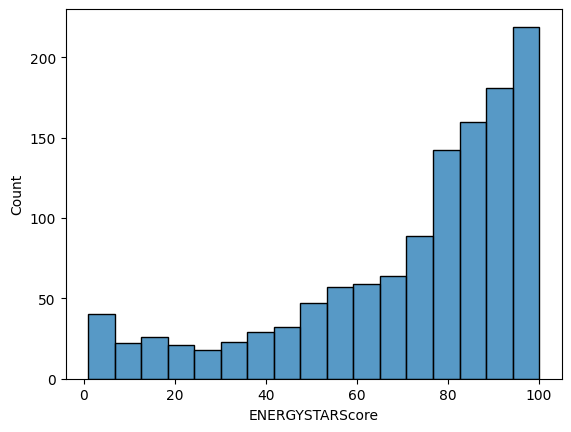

In [658]:
sns.histplot(NR_building_WO_outliers_consumption, x='ENERGYSTARScore')

### Attribution de la moyenne au valeur NA de ENERGYSTARScore

# Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

## Traitement des données contre le dataLeakage

In [659]:
# Création de HasElectricity , HasSteam , HasGas , isMultiUsage, hasParking
NR_building_WO_outliers_consumption['HasElectricity'] = NR_building_WO_outliers_consumption['Electricity(kBtu)'] > 0
NR_building_WO_outliers_consumption['HasSteam'] = NR_building_WO_outliers_consumption['SteamUse(kBtu)'] > 0
NR_building_WO_outliers_consumption['HasGas'] = NR_building_WO_outliers_consumption['NaturalGas(kBtu)'] > 0
NR_building_WO_outliers_consumption['isMultiUsage'] = NR_building_WO_outliers_consumption['SecondLargestPropertyUseType'].notna()
NR_building_WO_outliers_consumption['HasParking'] = NR_building_WO_outliers_consumption['PropertyGFAParking'] > 0


C:\Users\Fabien\AppData\Local\Temp\ipykernel_1328\451653859.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consumption['HasElectricity'] = NR_building_WO_outliers_consumption['Electricity(kBtu)'] > 0
C:\Users\Fabien\AppData\Local\Temp\ipykernel_1328\451653859.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consumption['HasSteam'] = NR_building_WO_outliers_consumption['SteamUse(kBtu)'] > 0
C:\Users\Fabien\AppData\Local\Temp\ipykernel_1328\451653859.py:

In [660]:
dataLeakage_cols =['SiteEUI(kBtu/sf)','SiteEUIWN(kBtu/sf)','SiteEnergyUse(kBtu)',
                'SiteEnergyUseWN(kBtu)','SteamUse(kBtu)','Electricity(kBtu)','NaturalGas(kBtu)']
NR_building_WO_outliers_consumption.drop(dataLeakage_cols,axis=1,inplace=True)
NR_building_WO_outliers_consumption.head()

C:\Users\Fabien\AppData\Local\Temp\ipykernel_1328\377229166.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consumption.drop(dataLeakage_cols,axis=1,inplace=True)


,OSEBuildingID,BuildingType,PrimaryPropertyType,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,TotalGHGEmissions,GHGEmissionsIntensity,HasElectricity,HasSteam,HasGas,isMultiUsage,HasParking
6,10,NonResidential,Hotel,7,DOWNTOWN,47.61390,-122.33283,1926,1.0,11,83008,0,83008,Hotel,Hotel,81352.0,NaN,NaN,NaN,NaN,27.000000,176.14,2.12,True,False,True,False,False
7,11,NonResidential,Other,7,DOWNTOWN,47.61327,-122.33136,1926,1.0,8,102761,0,102761,Other - Entertainment/Public Assembly,Other - Entertainment/Public Assembly,102761.0,NaN,NaN,NaN,NaN,85.543794,221.51,2.16,True,True,True,False,False
22,28,SPS-District K-12,K-12 School,2,SOUTHEAST,47.54576,-122.26853,1961,1.0,2,56228,0,56228,K-12 School,K-12 School,58916.0,NaN,NaN,NaN,NaN,95.000000,38.53,0.69,True,False,True,False,False
23,29,NonResidential,Hotel,4,NORTHEAST,47.65959,-122.31755,2001,1.0,6,88592,30586,58006,"Hotel, Parking",Hotel,58006.0,Parking,30586.0,NaN,NaN,84.000000,90.01,1.02,True,False,True,True,True
25,31,NonResidential,Other,7,DOWNTOWN,47.61500,-122.33081,1930,1.0,2,67224,0,67224,Automobile Dealership,Automobile Dealership,67224.0,NaN,NaN,NaN,NaN,97.934854,9.13,0.14,True,False,False,False,False


# Préparation des features pour la modélisation

A réaliser :
* ~~Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.~~
* ~~Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.~~
* ~~Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn~~
* ~~Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).~~
* ~~Séparez votre jeu de données en un Pandas DataFrame X (ensemble de features) et Pandas Series y (votre target).~~
* ~~Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder~~

## Distribution de la valeur cible **TotalGHGEmissions**

<Axes: xlabel='TotalGHGEmissions', ylabel='Count'>

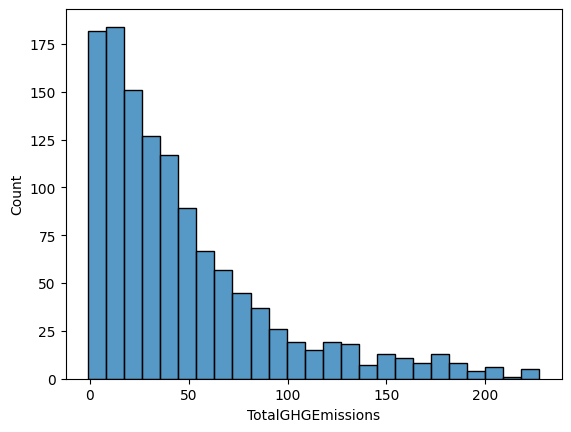

In [661]:
sns.histplot(data= NR_building_WO_outliers_consumption['TotalGHGEmissions'])


## Analyse par matrice de correlation et suppression des variables redondantes (QUANTITATIF)

### Heatmap globale

<Axes: >

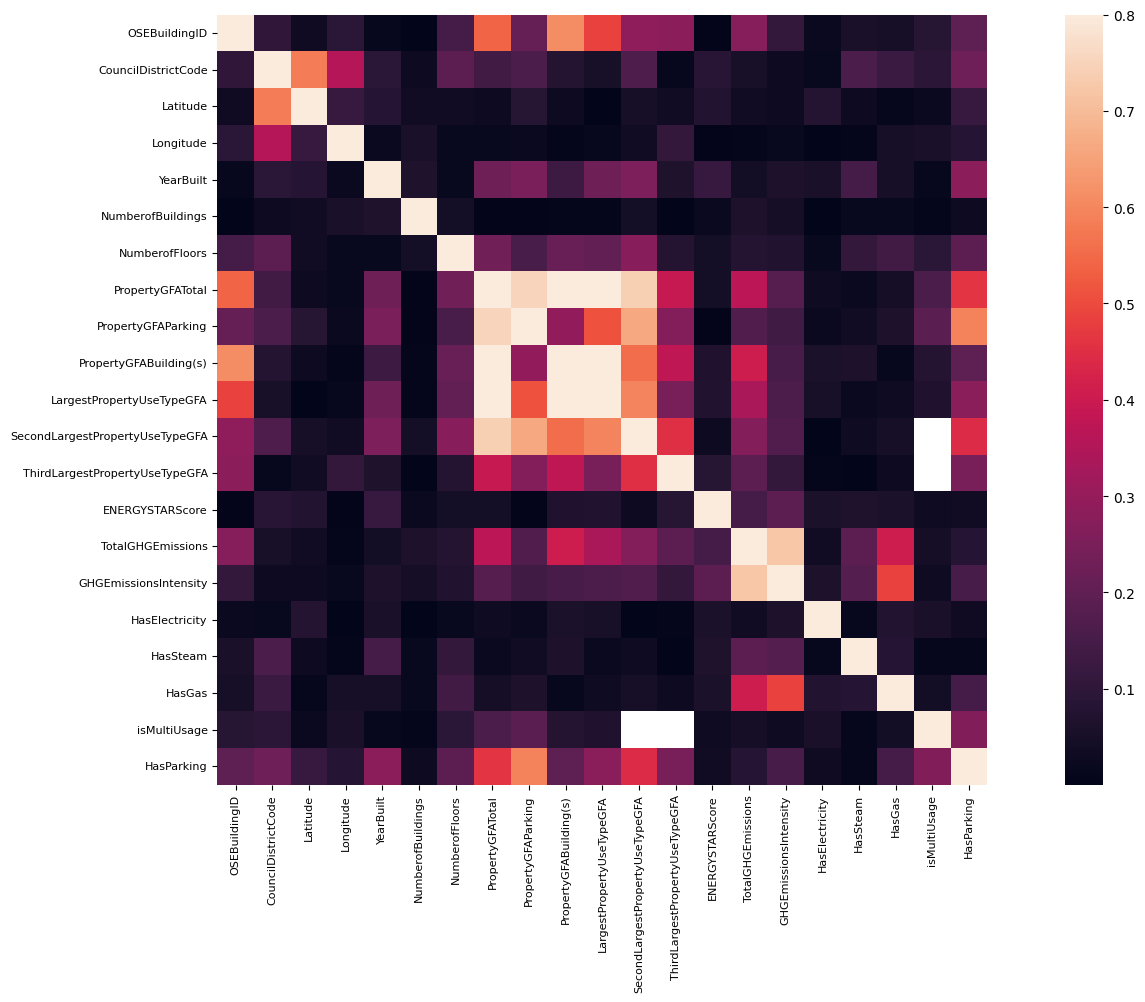

In [662]:
features_numerique = NR_building_WO_outliers_consumption.columns[(NR_building_WO_outliers_consumption.dtypes != object)]
corr_mat  = NR_building_WO_outliers_consumption[features_numerique].corr().abs()
plt.figure(figsize=(20,10))
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
sns.heatmap(corr_mat,annot=False,vmax=0.8,square=True)

### Heatmap des 10 variables les plus corrélées à ma variable cible

Index(['TotalGHGEmissions', 'GHGEmissionsIntensity', 'HasGas',
       'PropertyGFABuilding(s)', 'PropertyGFATotal',
       'LargestPropertyUseTypeGFA', 'OSEBuildingID',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA',
       'HasSteam'],
      dtype='object')


<Axes: >

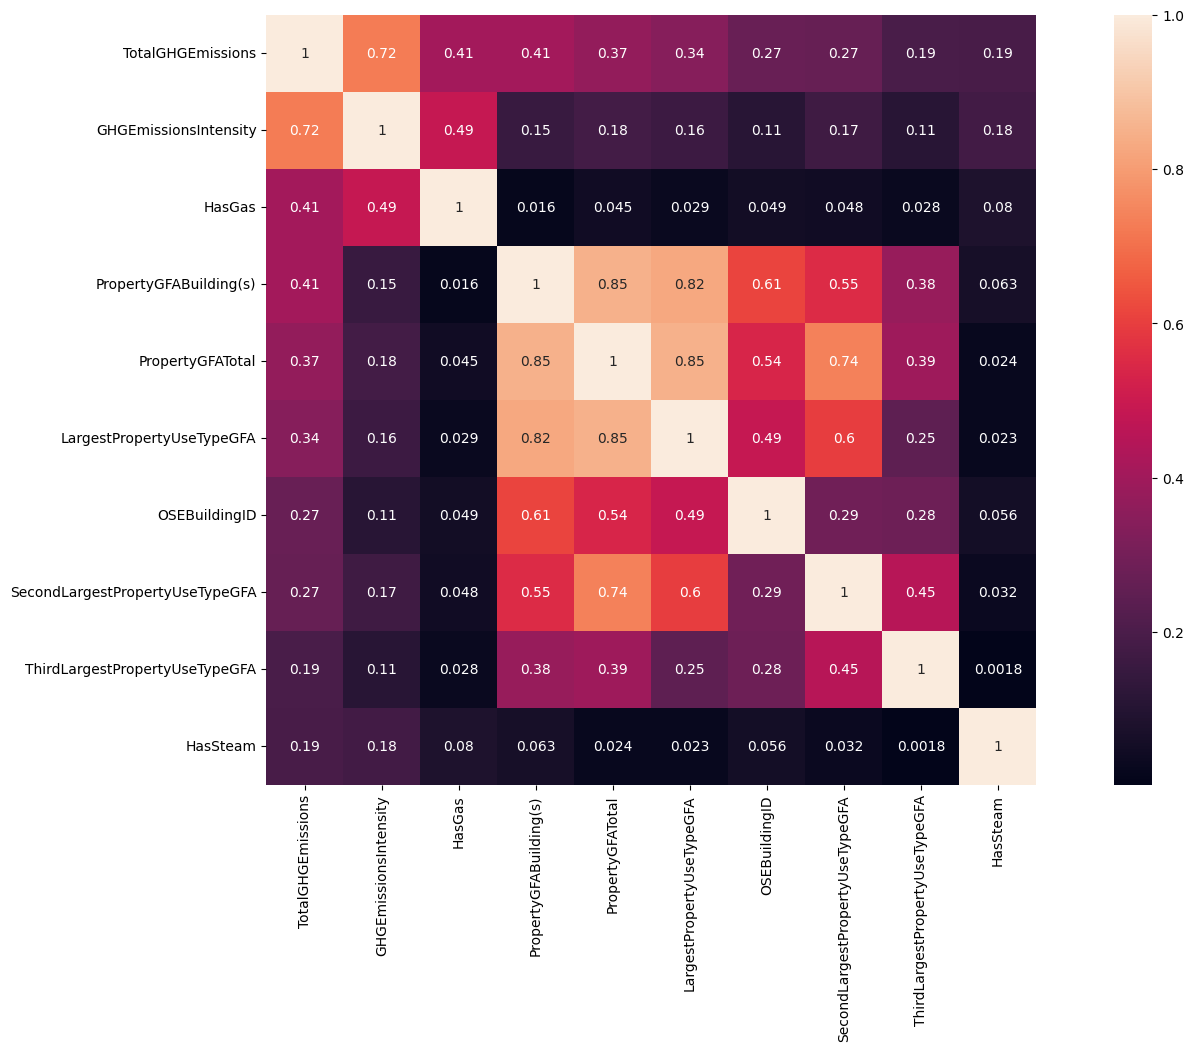

In [663]:
top_cols = corr_mat.nlargest(10,['TotalGHGEmissions'])['TotalGHGEmissions'].index
print(top_cols)
top_cols_corr = NR_building_WO_outliers_consumption[top_cols].corr().abs()
plt.figure(figsize=(20,10))
sns.heatmap(data = top_cols_corr,annot=True, square=True)


In [664]:
redundante_cols = ['GHGEmissionsIntensity','PropertyGFATotal','LargestPropertyUseTypeGFA',
                   'PropertyGFAParking','SecondLargestPropertyUseTypeGFA',
                   'ThirdLargestPropertyUseTypeGFA','ListOfAllPropertyUseTypes',
                   'LargestPropertyUseType','SecondLargestPropertyUseType','ThirdLargestPropertyUseType']
#'OSEBuildingID',
NR_building_WO_outliers_consumption.drop(redundante_cols, axis=1,inplace= True)
NR_building_WO_outliers_consumption.columns

C:\Users\Fabien\AppData\Local\Temp\ipykernel_1328\3959703436.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consumption.drop(redundante_cols, axis=1,inplace= True)


Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFABuilding(s)', 'ENERGYSTARScore', 'TotalGHGEmissions',
       'HasElectricity', 'HasSteam', 'HasGas', 'isMultiUsage', 'HasParking'],
      dtype='object')

## Analyse par matrice de contingence (QUALITATIF)

<Axes: xlabel='Neighborhood', ylabel='PrimaryPropertyType'>

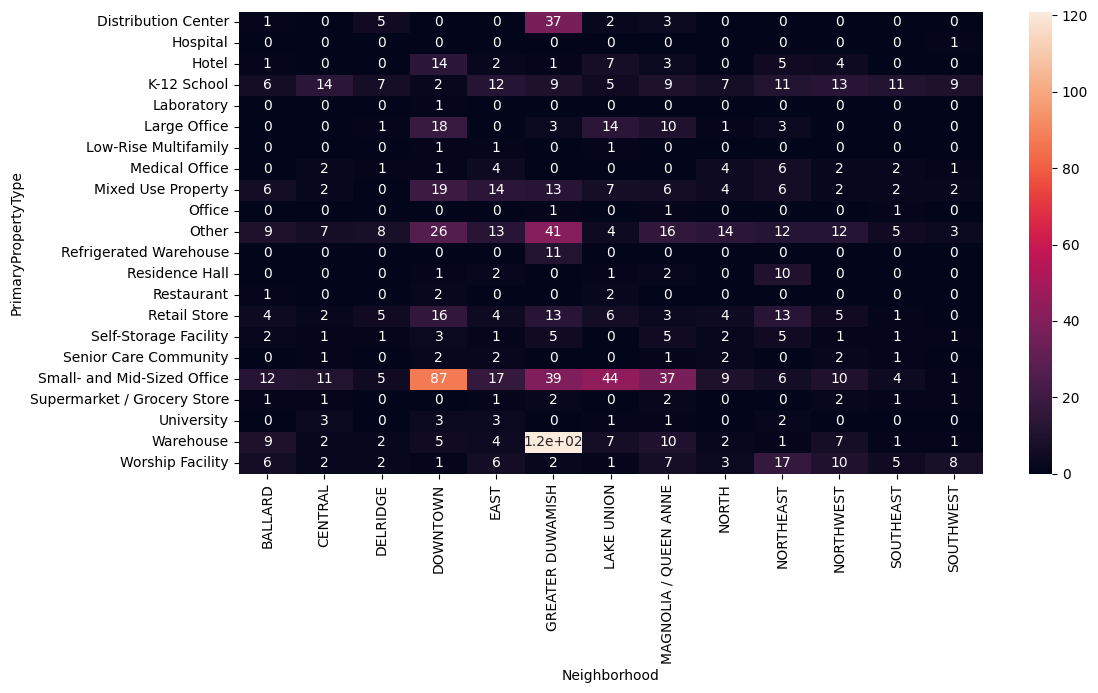

In [665]:
matrice_contingence = pd.crosstab(NR_building_WO_outliers_consumption['PrimaryPropertyType'],NR_building_WO_outliers_consumption['Neighborhood'])
plt.figure(figsize=(12,6))
sns.heatmap(matrice_contingence,annot=True)

<Axes: xlabel='BuildingType', ylabel='PrimaryPropertyType'>

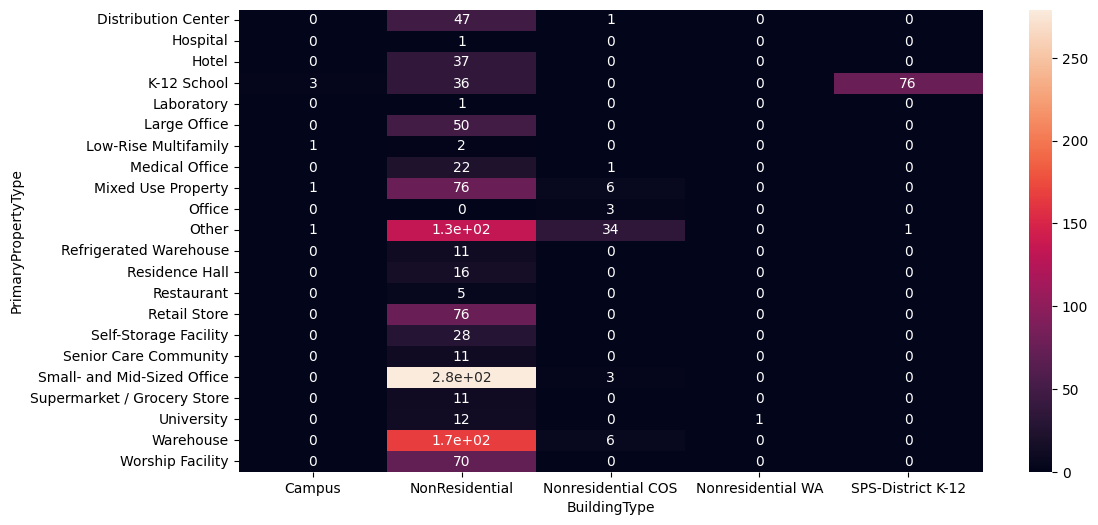

In [666]:
matrice_contingence = pd.crosstab(NR_building_WO_outliers_consumption['PrimaryPropertyType'],NR_building_WO_outliers_consumption['BuildingType'])
plt.figure(figsize=(12,6))
sns.heatmap(matrice_contingence,annot=True)

**Conclusion :** Il semblerait que la diversité des BuildingType ne soit pas necessaire. Nous garderons uniquement les primarypropertyType

In [667]:
NR_building_WO_outliers_consumption.drop(['BuildingType'], axis=1, inplace=True)

C:\Users\Fabien\AppData\Local\Temp\ipykernel_1328\221977777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NR_building_WO_outliers_consumption.drop(['BuildingType'], axis=1, inplace=True)


In [668]:
NR_building_WO_outliers_consumption.columns

Index(['OSEBuildingID', 'PrimaryPropertyType', 'CouncilDistrictCode',
       'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFABuilding(s)',
       'ENERGYSTARScore', 'TotalGHGEmissions', 'HasElectricity', 'HasSteam',
       'HasGas', 'isMultiUsage', 'HasParking'],
      dtype='object')

<Axes: xlabel='HasParking', ylabel='PrimaryPropertyType'>

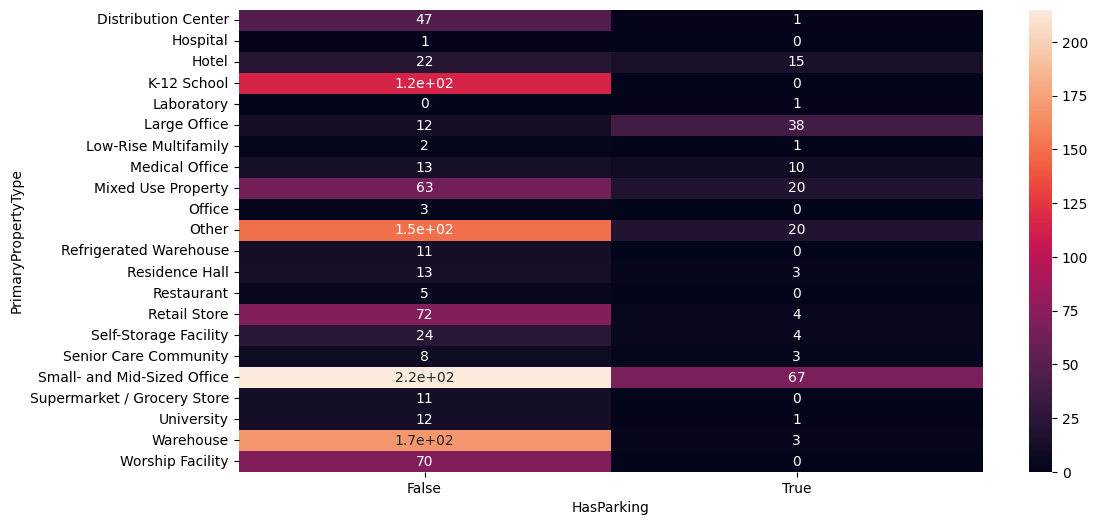

In [669]:
matrice_contingence = pd.crosstab(NR_building_WO_outliers_consumption['PrimaryPropertyType'],NR_building_WO_outliers_consumption['HasParking'])
plt.figure(figsize=(12,6))
sns.heatmap(matrice_contingence,annot=True)

## Encodage des variable qualitatives

### Encodage de buildingType

In [670]:
# OHE_BuildingType = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas')
# encoded_df =OHE_BuildingType.fit_transform(NR_building_WO_outliers_consumption[['BuildingType']])
# NR_building_WO_outliers_consumption = pd.concat([NR_building_WO_outliers_consumption,encoded_df.astype(bool)],axis=1).drop('BuildingType', axis=1)

### Encodage de PrimaryPropertyType

In [671]:
OHE_PrimaryPropertyType = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
encoded_df = OHE_PrimaryPropertyType.fit_transform(NR_building_WO_outliers_consumption[['PrimaryPropertyType']])
NR_building_WO_outliers_consumption = pd.concat([NR_building_WO_outliers_consumption,encoded_df.astype(bool)],axis=1).drop(columns = 'PrimaryPropertyType')

### Encodage de Neighborhood

In [672]:
OHE_Neighborhood = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
encoded_df = OHE_Neighborhood.fit_transform(NR_building_WO_outliers_consumption[['Neighborhood']])
NR_building_WO_outliers_consumption = pd.concat([NR_building_WO_outliers_consumption,encoded_df.astype(bool)],axis=1).drop(columns = 'Neighborhood')

In [673]:
NR_building_WO_outliers_consumption.shape

(1229, 50)

## Pairplot des variables quantitatives

In [674]:
# Récupération des variables quantitatives
variables_pairplot = NR_building_WO_outliers_consumption.loc[:,(NR_building_WO_outliers_consumption.dtypes == int) | (NR_building_WO_outliers_consumption.dtypes == float)]

In [675]:
#sns.pairplot(data=variables_pairplot)

## Visualisation des variables qualitatives

### PLOT : Emissions en fonction des PrimaryPropertyTypes

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'PrimaryPropertyType_Distribution Center'),
  Text(1, 0, 'PrimaryPropertyType_Hospital'),
  Text(2, 0, 'PrimaryPropertyType_Hotel'),
  Text(3, 0, 'PrimaryPropertyType_K-12 School'),
  Text(4, 0, 'PrimaryPropertyType_Laboratory'),
  Text(5, 0, 'PrimaryPropertyType_Large Office'),
  Text(6, 0, 'PrimaryPropertyType_Low-Rise Multifamily'),
  Text(7, 0, 'PrimaryPropertyType_Medical Office'),
  Text(8, 0, 'PrimaryPropertyType_Mixed Use Property'),
  Text(9, 0, 'PrimaryPropertyType_Office'),
  Text(10, 0, 'PrimaryPropertyType_Other'),
  Text(11, 0, 'PrimaryPropertyType_Refrigerated Warehouse'),
  Text(12, 0, 'PrimaryPropertyType_Residence Hall'),
  Text(13, 0, 'PrimaryPropertyType_Restaurant'),
  Text(14, 0, 'PrimaryPropertyType_Retail Store'),
  Text(15, 0, 'PrimaryPropertyType_Self-Storage Facility'),
  Text(16, 0, 'PrimaryPropertyType_Senior Care Community

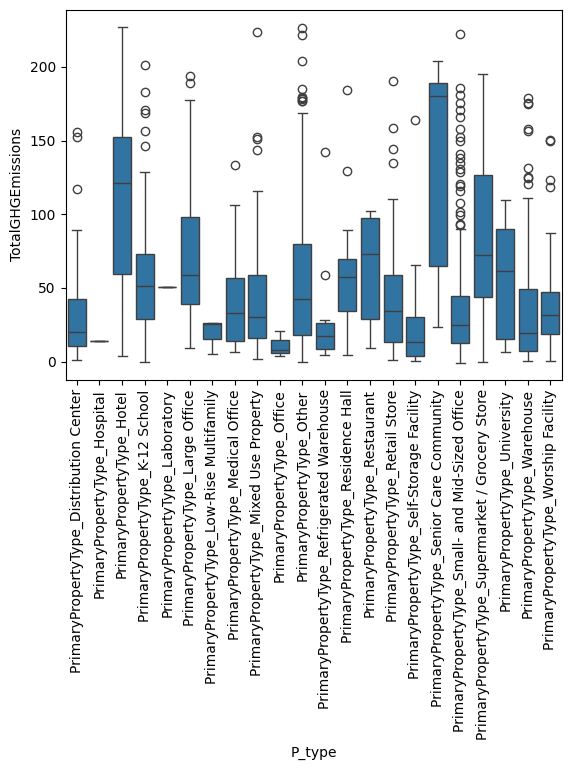

In [676]:
PrimaryPropertyType_cols = []
for col in NR_building_WO_outliers_consumption.columns:
    if col.startswith('PrimaryPropertyType'):
        PrimaryPropertyType_cols.append(col)
        
df_PrimaryPropertyType = NR_building_WO_outliers_consumption.melt(id_vars='TotalGHGEmissions',
                                                      value_name='Presence',
                                                      var_name='P_type',
                                                      value_vars=PrimaryPropertyType_cols)
df_PrimaryPropertyType = df_PrimaryPropertyType[df_PrimaryPropertyType['Presence']==True]
sns.boxplot(data=df_PrimaryPropertyType, x='P_type', y='TotalGHGEmissions')
plt.xticks(rotation=90)


**Conclusion :** On constate que le type de batiment fait fortement varier la production de CO²

### PLOT : Emissions en fonction du type d'énergie

([0, 1, 2],
 [Text(0, 0, 'HasElectricity'), Text(1, 0, 'HasSteam'), Text(2, 0, 'HasGas')])

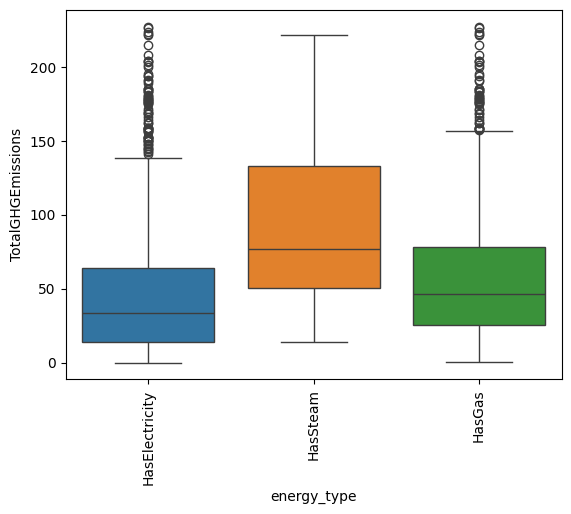

In [677]:
energy_cols = ['HasElectricity','HasSteam','HasGas']
        
df_HasEnergy = NR_building_WO_outliers_consumption.melt(id_vars='TotalGHGEmissions',
                                                      value_name='Presence',
                                                      var_name='energy_type',
                                                      value_vars=energy_cols)
df_HasEnergy = df_HasEnergy[df_HasEnergy['Presence']==True]
sns.boxplot(data=df_HasEnergy, x='energy_type', y='TotalGHGEmissions', hue='energy_type')
plt.xticks(rotation=90)

**Conclusion :** On constate que les batiements aillant de la vapeur produisent plus de CO²

### PLOT : Energie star score en fonction du type d'energie

([0, 1, 2],
 [Text(0, 0, 'HasElectricity'), Text(1, 0, 'HasSteam'), Text(2, 0, 'HasGas')])

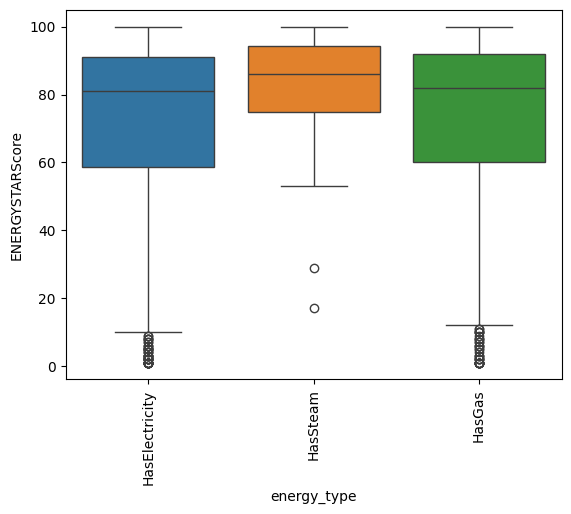

In [678]:
df_HasEnergy = NR_building_WO_outliers_consumption.melt(id_vars='ENERGYSTARScore',
                                                      value_name='Presence',
                                                      var_name='energy_type',
                                                      value_vars=energy_cols)
df_HasEnergy = df_HasEnergy[df_HasEnergy['Presence']==True]
sns.boxplot(data=df_HasEnergy, x='energy_type', y='ENERGYSTARScore', hue='energy_type')
plt.xticks(rotation=90)

### PLOT : Emissions en fonction du quartier

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Neighborhood_BALLARD'),
  Text(1, 0, 'Neighborhood_CENTRAL'),
  Text(2, 0, 'Neighborhood_DELRIDGE'),
  Text(3, 0, 'Neighborhood_DOWNTOWN'),
  Text(4, 0, 'Neighborhood_EAST'),
  Text(5, 0, 'Neighborhood_GREATER DUWAMISH'),
  Text(6, 0, 'Neighborhood_LAKE UNION'),
  Text(7, 0, 'Neighborhood_MAGNOLIA / QUEEN ANNE'),
  Text(8, 0, 'Neighborhood_NORTH'),
  Text(9, 0, 'Neighborhood_NORTHEAST'),
  Text(10, 0, 'Neighborhood_NORTHWEST'),
  Text(11, 0, 'Neighborhood_SOUTHEAST'),
  Text(12, 0, 'Neighborhood_SOUTHWEST')])

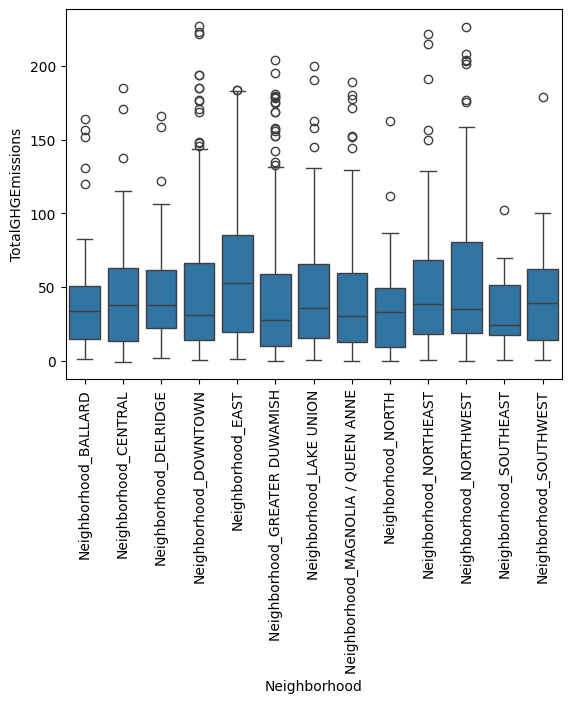

In [679]:
Neighborhood_cols = []
for col in NR_building_WO_outliers_consumption.columns:
    if col.startswith('Neighborhood'):
        Neighborhood_cols.append(col)
        
df_Neighborhood = NR_building_WO_outliers_consumption.melt(id_vars='TotalGHGEmissions',
                                                      value_name='Presence',
                                                      var_name='Neighborhood',
                                                      value_vars=Neighborhood_cols)
df_Neighborhood = df_Neighborhood[df_Neighborhood['Presence']==True]
sns.boxplot(data=df_Neighborhood, x='Neighborhood', y='TotalGHGEmissions')
plt.xticks(rotation=90)

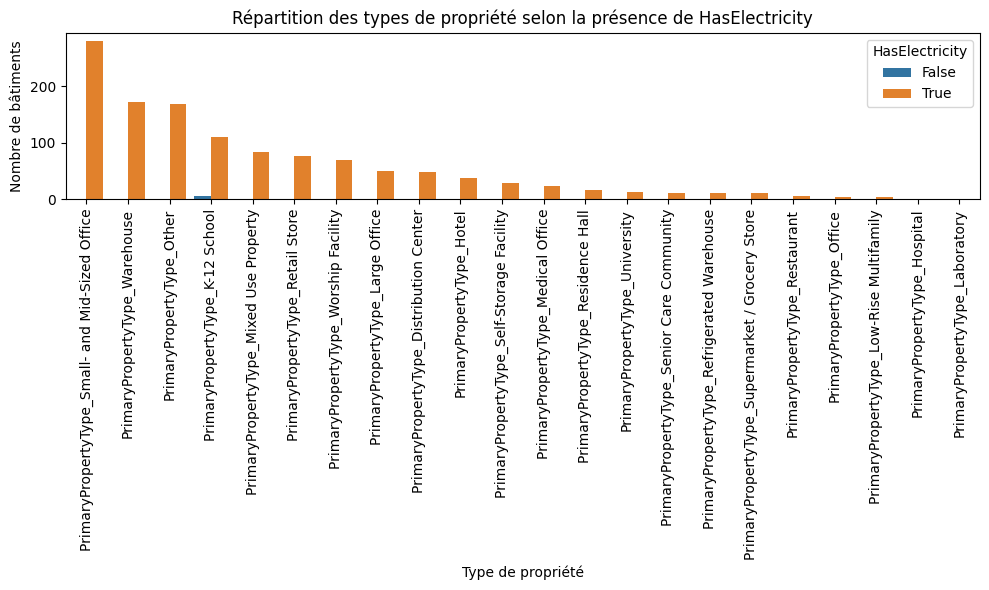

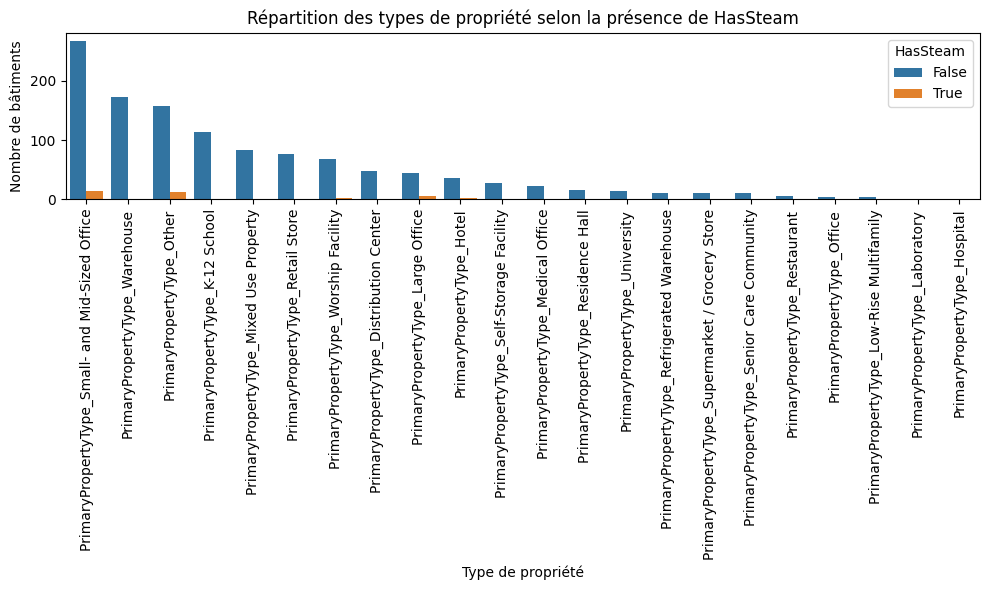

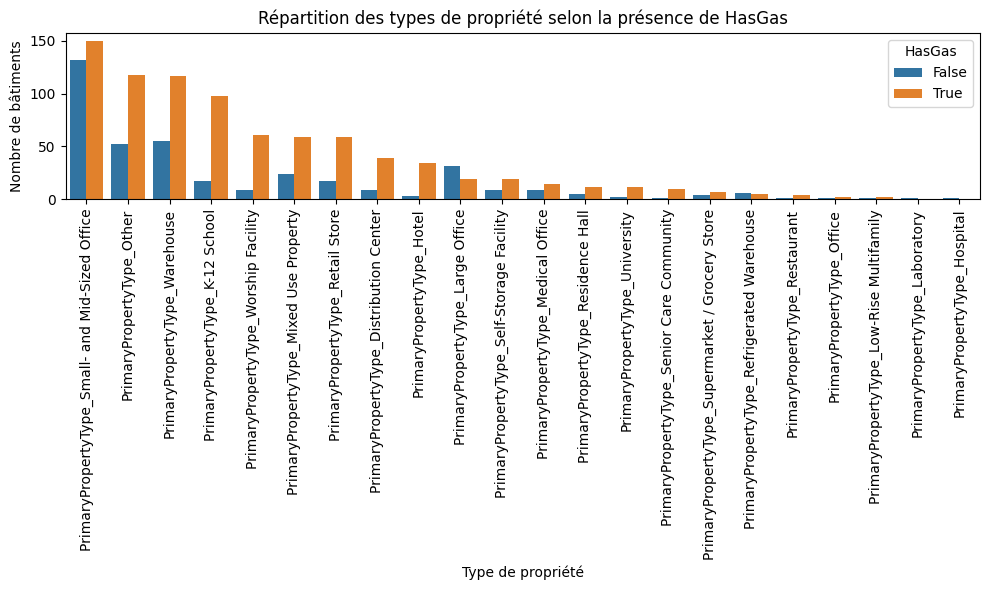

In [680]:
for var in energy_cols:
    energy_var = var

    # Préparation du DataFrame en format long
    df_melted = NR_building_WO_outliers_consumption.melt(
        id_vars=[energy_var],
        value_vars=PrimaryPropertyType_cols,
        var_name='PropertyType',
        value_name='Presence'
    )

    # Filtrer uniquement les lignes où Presence == 1
    df_filtered = df_melted[df_melted['Presence'] == 1]

    # Grouper par type de propriété et présence d'énergie
    grouped = df_filtered.groupby(['PropertyType', energy_var]).size().reset_index(name='Count').sort_values(by='Count',ascending=False)

    # Tracé du barplot avec hue pour empiler
    plt.figure(figsize=(10, 6))
    sns.barplot(data=grouped, x='PropertyType', y='Count', hue=energy_var)
    plt.title(f"Répartition des types de propriété selon la présence de {energy_var}")
    plt.xlabel("Type de propriété")
    plt.ylabel("Nombre de bâtiments")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


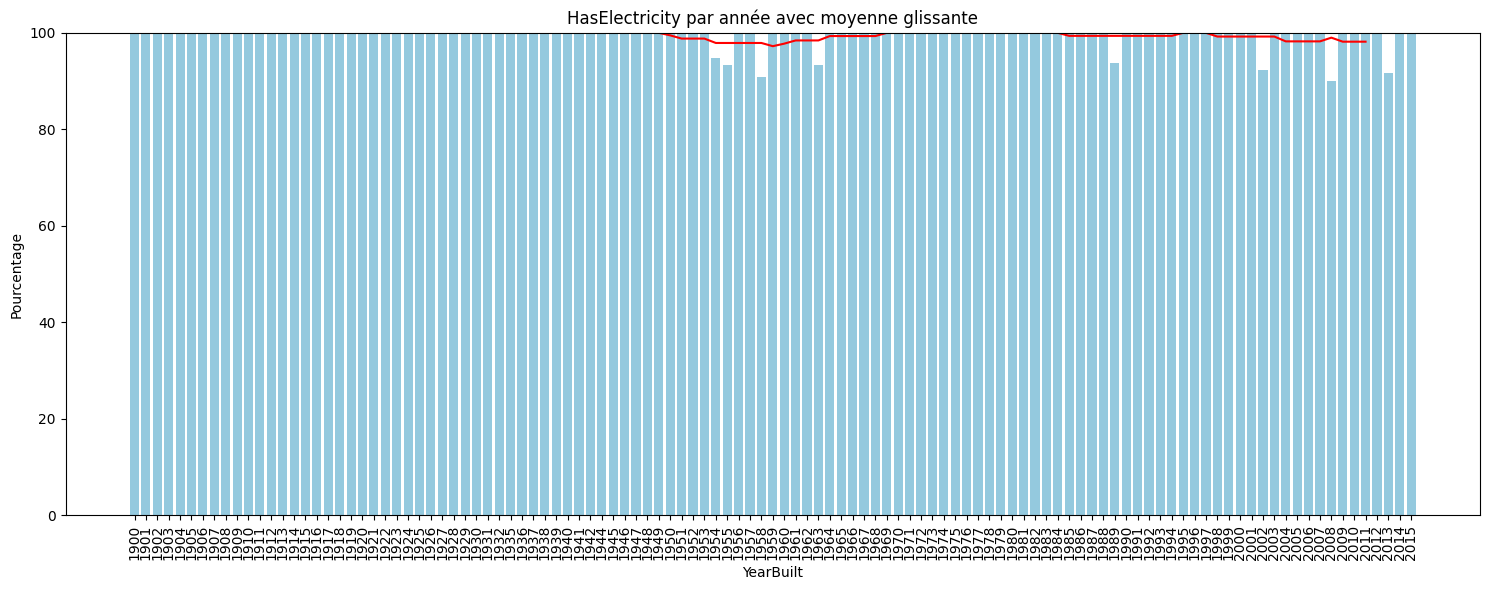

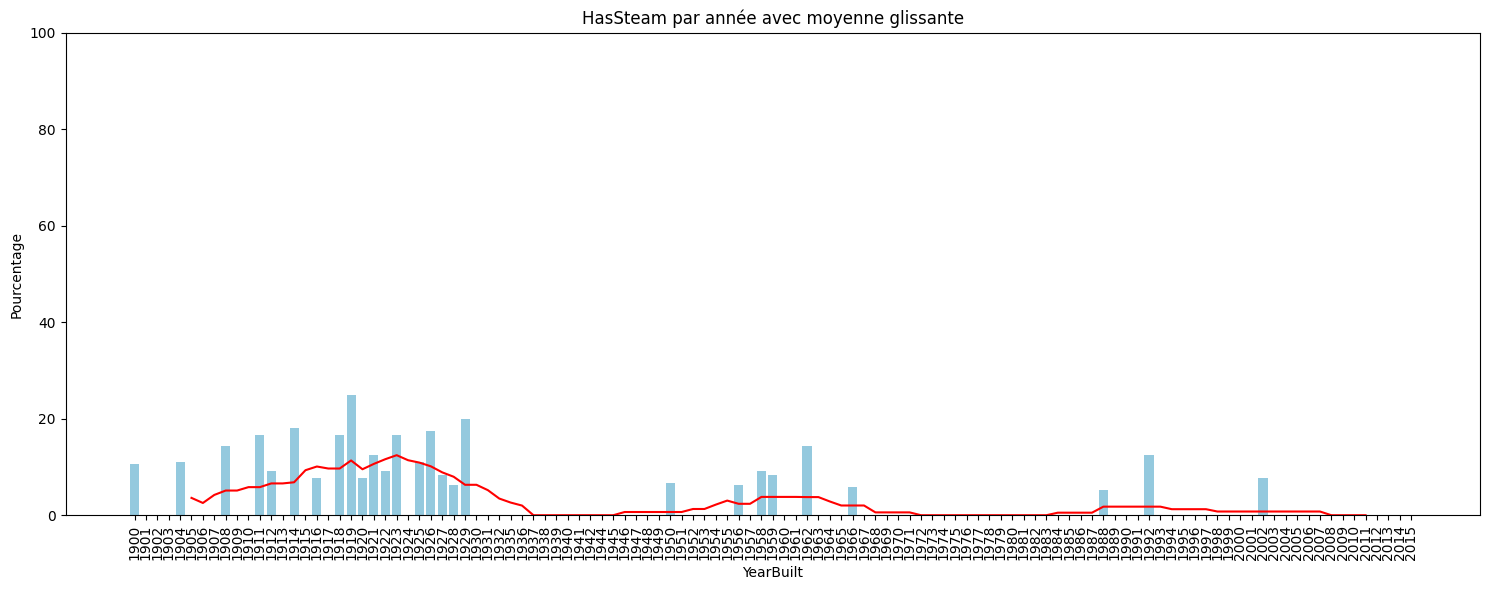

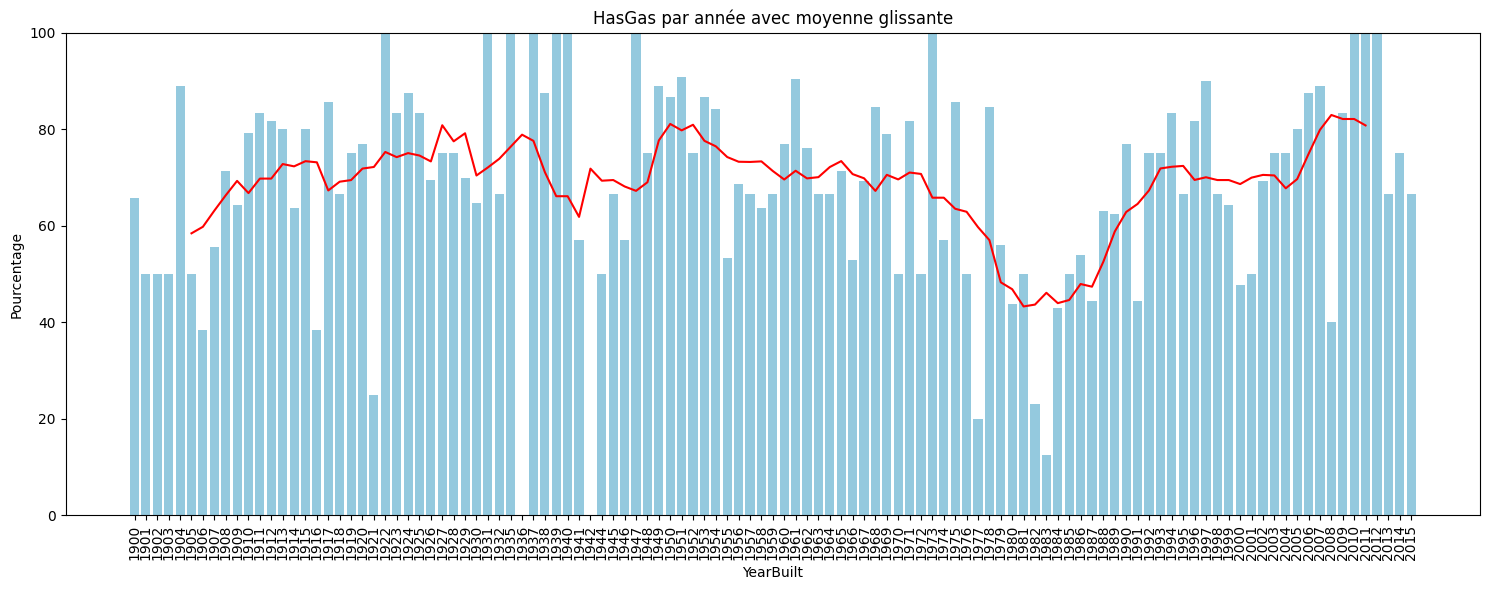

In [681]:
energies = ['HasElectricity','HasSteam','HasGas']

Energy_per_year = NR_building_WO_outliers_consumption[['YearBuilt','HasElectricity','HasSteam','HasGas']]
total_bat = Energy_per_year.groupby('YearBuilt').size().reset_index(name='Total')
Energy_per_year = Energy_per_year.groupby('YearBuilt').sum().reset_index()
Energy_per_year_percentage = Energy_per_year.merge(total_bat,on='YearBuilt')
Energy_per_year_percentage[energies] = Energy_per_year_percentage[energies].apply(lambda x : x / Energy_per_year_percentage['Total']*100)
for energy in energies:
    Energy_per_year_percentage[f'10Years_rolling_{energy}'] = Energy_per_year_percentage[energy].rolling(window=10, center=True).mean()

    Energy_per_year_percentage['YearBuilt'] = Energy_per_year_percentage['YearBuilt'].astype(str)



    fig, ax = plt.subplots(figsize=(15, 6))

    # Barplot
    sns.barplot(data=Energy_per_year_percentage, x='YearBuilt', y=energy, ax=ax, color='skyblue')

    # Lineplot
    sns.lineplot(data=Energy_per_year_percentage, x='YearBuilt', y=f'10Years_rolling_{energy}', ax=ax, color='red')

    # Contraindre les limites de l'axe Y
    ax.set_ylim(0, 100)  # Par exemple, si tu veux afficher des pourcentages

    # Améliorer la lisibilité
    ax.set_ylabel('Pourcentage')
    plt.title(f"{energy} par année avec moyenne glissante")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()




**Conclusion :**  
On constate 3 choses :
 - Pratiquement tous les batiments ont de l'electricité
 - Très peu de batiment ont de la vapeur
 - La répartition de présence de gaz est différente selon le type de batiment

On sait aussi que dépendement de l'année de construction, les batiments ont plus ou moins accès à la vapeur et au gaz

# EMISSIONS CO²

## Séparation du jeu de donnée en X et y

In [682]:
y = NR_building_WO_outliers_consumption['TotalGHGEmissions']
X = NR_building_WO_outliers_consumption.drop('TotalGHGEmissions', axis=1)

In [683]:
y.head()

6     176.14
7     221.51
22     38.53
23     90.01
25      9.13
Name: TotalGHGEmissions, dtype: float64

In [684]:
X.head()

,OSEBuildingID,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),ENERGYSTARScore,HasElectricity,HasSteam,HasGas,isMultiUsage,HasParking,PrimaryPropertyType_Distribution Center,PrimaryPropertyType_Hospital,PrimaryPropertyType_Hotel,PrimaryPropertyType_K-12 School,PrimaryPropertyType_Laboratory,PrimaryPropertyType_Large Office,PrimaryPropertyType_Low-Rise Multifamily,PrimaryPropertyType_Medical Office,PrimaryPropertyType_Mixed Use Property,PrimaryPropertyType_Office,PrimaryPropertyType_Other,PrimaryPropertyType_Refrigerated Warehouse,PrimaryPropertyType_Residence Hall,PrimaryPropertyType_Restaurant,PrimaryPropertyType_Retail Store,PrimaryPropertyType_Self-Storage Facility,PrimaryPropertyType_Senior Care Community,PrimaryPropertyType_Small- and Mid-Sized Office,PrimaryPropertyType_Supermarket / Grocery Store,PrimaryPropertyType_University,PrimaryPropertyType_Warehouse,PrimaryPropertyType_Worship Facility,Neighborhood_BALLARD,Neighborhood_CENTRAL,Neighborhood_DELRIDGE,Neighborhood_DOWNTOWN,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST
6,10,7,47.61390,-122.33283,1926,1.0,11,83008,27.000000,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
7,11,7,47.61327,-122.33136,1926,1.0,8,102761,85.543794,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
22,28,2,47.54576,-122.26853,1961,1.0,2,56228,95.000000,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
23,29,4,47.65959,-122.31755,2001,1.0,6,58006,84.000000,True,False,True,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
25,31,7,47.61500,-122.33081,1930,1.0,2,67224,97.934854,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


## Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

## Séparation jeu apprentissage et test

In [685]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## DummyRegressor


In [686]:
# Dummy model est un model 'bete' de référence. il servira a constater de la performance ou non des autres modèles
dummy_model = DummyRegressor(strategy='mean')
Score_Dummy = cross_validate(dummy_model,X_train, y_train, cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
Dummy_results = pd.DataFrame(Score_Dummy)
Dummy_results


,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.000000,0.011377,-0.000719,-1801.688696,-33.175083
1,0.002000,0.002991,-0.004129,-1897.963227,-33.368658
2,0.001995,0.002992,-0.000133,-2118.168407,-34.059757
3,0.001994,0.002992,-0.016053,-2072.706285,-34.668185
4,0.002339,0.002981,-0.019837,-2413.157273,-35.707577


In [687]:
df_dummy = pd.DataFrame([Dummy_results.mean()])
df_dummy

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.001666,0.004667,-0.008174,-2060.736778,-34.195852


In [688]:
dummy_model.fit(X_train,y_train)
y_dummy_pred = dummy_model.predict(X_test)

In [689]:
print(r2_score(y_test,y_dummy_pred))
print(mean_squared_error(y_test,y_dummy_pred))
print(mean_absolute_error(y_test,y_dummy_pred))

-0.007488335876539409
1916.2837388698726
33.25812143843718


## LinearRegression

In [690]:
STDScaler = StandardScaler()
X_train_normalized = pd.DataFrame(STDScaler.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
X_test_normalized = pd.DataFrame(STDScaler.transform(X_test),columns=X_test.columns,index=X_test.index)

Linear_regression_model = LinearRegression()
Score_Linear_regression = cross_validate(Linear_regression_model,X_train_normalized, y_train, cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
results_Linear_regression = pd.DataFrame(Score_Linear_regression)
results_Linear_regression

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.055316,0.005388,0.494156,-910.719167,-23.397164
1,0.073837,0.006231,0.421060,-1094.287523,-24.947001
2,0.067041,0.005989,0.486294,-1087.970046,-23.110927
3,0.040191,0.004262,0.547438,-923.208724,-21.208344
4,0.017993,0.009686,0.547925,-1069.708230,-23.712373


In [691]:
df_Linear_regression = pd.DataFrame([results_Linear_regression.mean()])
df_Linear_regression

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.050876,0.006311,0.499375,-1017.178738,-23.275162


In [692]:
Linear_regression_model.fit(X_train_normalized,y_train)
y_LR_pred = Linear_regression_model.predict(X_test_normalized)

In [693]:
print(r2_score(y_test,y_LR_pred))
print(mean_squared_error(y_test,y_LR_pred))
print(mean_absolute_error(y_test,y_LR_pred))

0.4490643988992755
1047.9018922192183
23.743249656284064


## SVR

In [694]:
SVR_model = SVR()
Score_SVR = cross_validate(SVR_model,X_train_normalized,y_train,cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
results_SVR = pd.DataFrame(Score_SVR)
results_SVR

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.051805,0.026430,0.026552,-1752.589640,-28.829349
1,0.050536,0.029560,0.076595,-1745.380855,-27.971391
2,0.054001,0.032888,0.053613,-2004.339466,-28.770199
3,0.055730,0.029021,0.123310,-1788.412581,-27.246663
4,0.050657,0.027792,-0.031044,-2439.673725,-32.174210


In [695]:
df_SVR = pd.DataFrame([results_SVR.mean()])
df_SVR

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,0.052546,0.029138,0.049805,-1946.079253,-28.998362


In [696]:
SVR_model.fit(X_train_normalized,y_train)
y_SVR_pred = SVR_model.predict(X_test_normalized)

In [697]:
print(r2_score(y_test,y_SVR_pred))
print(mean_squared_error(y_test,y_SVR_pred))
print(mean_absolute_error(y_test,y_SVR_pred))

0.08432148590313349
1741.6577285430517
27.371065307526592


## RandomForestRegressor

In [698]:
Random_forest_model = RandomForestRegressor(random_state=42)
Score_Random_forest = cross_validate(Random_forest_model, X_train,y_train,cv=5, scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
results_Random_forest = pd.DataFrame(Score_Random_forest)
results_Random_forest

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,1.286076,0.022452,0.488048,-921.715418,-21.769266
1,1.190009,0.028321,0.374247,-1182.771228,-23.877473
2,1.208945,0.024058,0.444344,-1176.815736,-23.103493
3,1.224764,0.023221,0.524556,-969.886328,-20.358079
4,1.177475,0.022364,0.547095,-1071.672009,-23.506130


In [699]:
df_Random_forest = pd.DataFrame([results_Random_forest.mean()])
df_Random_forest

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error
0,1.217454,0.024083,0.475658,-1064.572144,-22.522888


In [700]:
Random_forest_model.fit(X_train,y_train)
y_RF_pred = Random_forest_model.predict(X_test)

In [701]:
print(r2_score(y_test,y_RF_pred))
print(mean_squared_error(y_test,y_RF_pred))
print(mean_absolute_error(y_test,y_RF_pred))

0.4158907780637513
1110.9994665561385
22.386922357723577


## RIDGE

In [702]:
ridge_model = Ridge(random_state=42)
score_Ridge = cross_validate(ridge_model, X_train_normalized,y_train,cv=5,scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'])
results_ridge = pd.DataFrame(score_Ridge).mean()
results_ridge


fit_time                           0.004920
score_time                         0.004276
test_r2                            0.499510
test_neg_mean_squared_error    -1016.935624
test_neg_mean_absolute_error     -23.266639
dtype: float64

In [703]:
X_train_normalized

,OSEBuildingID,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFABuilding(s),ENERGYSTARScore,HasElectricity,HasSteam,HasGas,isMultiUsage,HasParking,PrimaryPropertyType_Distribution Center,PrimaryPropertyType_Hospital,PrimaryPropertyType_Hotel,PrimaryPropertyType_K-12 School,PrimaryPropertyType_Laboratory,PrimaryPropertyType_Large Office,PrimaryPropertyType_Low-Rise Multifamily,PrimaryPropertyType_Medical Office,PrimaryPropertyType_Mixed Use Property,PrimaryPropertyType_Office,PrimaryPropertyType_Other,PrimaryPropertyType_Refrigerated Warehouse,PrimaryPropertyType_Residence Hall,PrimaryPropertyType_Restaurant,PrimaryPropertyType_Retail Store,PrimaryPropertyType_Self-Storage Facility,PrimaryPropertyType_Senior Care Community,PrimaryPropertyType_Small- and Mid-Sized Office,PrimaryPropertyType_Supermarket / Grocery Store,PrimaryPropertyType_University,PrimaryPropertyType_Warehouse,PrimaryPropertyType_Worship Facility,Neighborhood_BALLARD,Neighborhood_CENTRAL,Neighborhood_DELRIDGE,Neighborhood_DOWNTOWN,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_SOUTHEAST,Neighborhood_SOUTHWEST
1861,0.430863,1.342790,0.830677,-1.595242,-0.056945,0.0,-0.478406,-0.333705,-2.222101,0.071502,-0.186378,0.673901,-0.937839,-0.431006,-0.21388,-0.031911,-0.183436,-0.315520,-0.031911,-0.205956,-0.031911,-0.147748,-0.261684,-0.045152,-0.397282,-0.096126,-0.115767,-0.045152,-0.261684,-0.158196,-0.106381,-0.549533,-0.101378,-0.096126,2.517106,-0.238724,-0.219031,-0.200528,-0.177425,-0.434320,-0.279018,-0.579308,-0.311606,3.112038,-0.211266,-0.291529,-0.233925,-0.174351,-0.136575
2711,0.682177,1.342790,-0.291468,0.080077,-1.701502,0.0,0.883915,-0.644114,0.699861,0.071502,-0.186378,0.673901,-0.937839,-0.431006,-0.21388,-0.031911,-0.183436,-0.315520,-0.031911,-0.205956,-0.031911,-0.147748,-0.261684,-0.045152,2.517106,-0.096126,-0.115767,-0.045152,-0.261684,-0.158196,-0.106381,-0.549533,-0.101378,-0.096126,-0.397282,-0.238724,-0.219031,-0.200528,-0.177425,2.302451,-0.279018,-0.579308,-0.311606,-0.321333,-0.211266,-0.291529,-0.233925,-0.174351,-0.136575
2414,0.589306,-0.056464,0.645550,-0.333726,1.525553,0.0,0.338987,0.037793,-0.983525,0.071502,-0.186378,-1.483898,-0.937839,-0.431006,-0.21388,-0.031911,-0.183436,-0.315520,-0.031911,-0.205956,-0.031911,-0.147748,-0.261684,-0.045152,-0.397282,-0.096126,-0.115767,-0.045152,-0.261684,-0.158196,-0.106381,1.819726,-0.101378,-0.096126,-0.397282,-0.238724,-0.219031,-0.200528,-0.177425,-0.434320,-0.279018,-0.579308,3.209182,-0.321333,-0.211266,-0.291529,-0.233925,-0.174351,-0.136575
912,0.154118,0.876372,1.063534,-2.224592,0.036143,0.0,0.338987,-0.985657,0.154910,0.071502,-0.186378,0.673901,1.066282,-0.431006,-0.21388,-0.031911,-0.183436,-0.315520,-0.031911,-0.205956,-0.031911,-0.147748,3.821410,-0.045152,-0.397282,-0.096126,-0.115767,-0.045152,-0.261684,-0.158196,-0.106381,-0.549533,-0.101378,-0.096126,-0.397282,-0.238724,4.565572,-0.200528,-0.177425,-0.434320,-0.279018,-0.579308,-0.311606,-0.321333,-0.211266,-0.291529,-0.233925,-0.174351,-0.136575
1464,0.290947,-1.455717,-1.920265,0.464925,0.687760,0.0,-0.478406,-0.677234,-0.795861,0.071502,-0.186378,0.673901,-0.937839,-0.431006,-0.21388,-0.031911,-0.183436,-0.315520,-0.031911,-0.205956,-0.031911,-0.147748,-0.261684,-0.045152,-0.397282,-0.096126,-0.115767,-0.045152,-0.261684,-0.158196,-0.106381,-0.549533,-0.101378,-0.096126,2.517106,-0.238724,-0.219031,-0.200528,-0.177425,-0.434320,-0.279018,1.726197,-0.311606,-0.321333,-0.211266,-0.291529,-0.233925,-0.174351,-0.136575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2643,0.656339,-0.056464,0.933326,0.795083,-0.181063,0.0,0.338987,-0.493602,0.142454,0.071502,-0.186378,0.673901,1.066282,-0.43100

## Comparaison totale

In [704]:
name = ['RandomForestRegressor','SVR','LinearRegression',"dummy"]
score_total = pd.concat([df_Random_forest,df_SVR,df_Linear_regression,df_dummy])
score_total['nom'] = name
score_total

,fit_time,score_time,test_r2,test_neg_mean_squared_error,test_neg_mean_absolute_error,nom
0,1.217454,0.024083,0.475658,-1064.572144,-22.522888,RandomForestRegressor
0,0.052546,0.029138,0.049805,-1946.079253,-28.998362,SVR
0,0.050876,0.006311,0.499375,-1017.178738,-23.275162,LinearRegression
0,0.001666,0.004667,-0.008174,-2060.736778,-34.195852,dummy


**Conclusion :** Le model SVR n'est pas satisfaisant comparé à la RF et LR. LR à les meilleurs performances.

## Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

## RANDOM FOREST

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42],
 [Text(0, 0, 'PropertyGFABuilding(s)'),
  Text(1, 0, 'HasGas'),
  Text(2, 0, 'ENERGYSTARScore'),
  Text(3, 0, 'OSEBuildingID'),
  Text(4, 0, 'YearBuilt'),
  Text(5, 0, 'Longitude'),
  Text(6, 0, 'Latitude'),
  Text(7, 0, 'HasSteam'),
  Text(8, 0, 'NumberofFloors'),
  Text(9, 0, 'PrimaryPropertyType_Hotel'),
  Text(10, 0, 'PrimaryPropertyType_Senior Care Community'),
  Text(11, 0, 'PrimaryPropertyType_Other'),
  Text(12, 0, 'PrimaryPropertyType_Large Office'),
  Text(13, 0, 'PrimaryPropertyType_Warehouse'),
  Text(14, 0, 'CouncilDistrictCode'),
  Text(15, 0, 'Neighborhood_EAST'),
  Text(16, 0, 'NumberofBuildings'),
  Text(17, 0, 'isMultiUsage'),
  Text(18, 0, 'PrimaryPropertyType_Supermarket / Grocery Store'),
  Text(19, 0, 'HasParking'),
  T

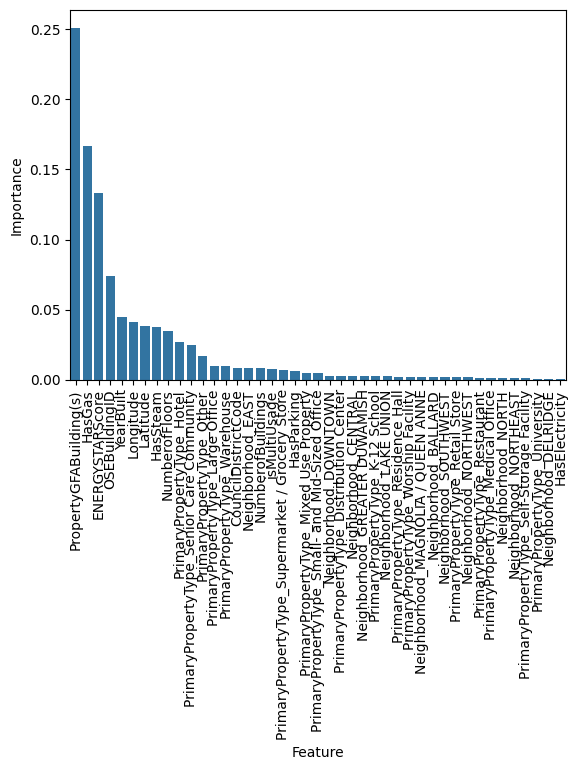

In [705]:
RF_importance = Random_forest_model.feature_importances_
feature_names = X_train.columns

df_RF_importances = pd.DataFrame({'Feature' : feature_names,'Importance':RF_importance}).sort_values(by='Importance', ascending=False)
sns.barplot(data=df_RF_importances.loc[:9,:], x='Feature', y='Importance')
plt.xticks(rotation=90)


In [706]:
params = {
    'n_estimators': [100,150], #FBL : nombre d'arbre dans la foret
    'max_depth':[20,30], #FBL : profondeur maximale (nombre de branches)
    'min_samples_split':[5,6], #FBL : Nombre de divisions à chaque noeud de l'arbre
    'min_samples_leaf':[1,5],
    'max_features': ['log2', 'sqrt'],
    'bootstrap': [True, False]
    

}
params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True]
}
RF_grid_search = GridSearchCV(estimator=Random_forest_model,param_grid=params,cv=5,scoring='r2',n_jobs=-1,verbose=1)
RF_grid_search.fit(X_train,y_train)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2', 0.5],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='r2', verbose=1)

In [707]:
best_param_random_forest = RF_grid_search.best_params_
print(best_param_random_forest)

{'bootstrap': True, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [708]:
final_random_forest_reg = RandomForestRegressor(**best_param_random_forest,random_state=42)
print(final_random_forest_reg.get_params())
final_random_forest_reg.fit(X_train,y_train)
y_final_pred = final_random_forest_reg.predict(X_test)

print(mean_absolute_error(y_test,y_final_pred))
print(mean_squared_error(y_test,y_final_pred))
print(r2_score(y_test,y_final_pred))

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
22.249353858003815
1066.6249873454256
0.43922071053072254


## LINEAR REGRESSION

In [709]:
ridge_model.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': 42,
 'solver': 'auto',
 'tol': 0.0001}

In [713]:
R_params = {
    'alpha': [0.01,0.02,0.05,0.1,0.5,0.8,1],
    'copy_X': [True,False],
    'max_iter': [1,5,10,15,20,None],
    'fit_intercept': [True,False],
    'positive': [False]
}
LR_gridsearch = GridSearchCV(ridge_model,cv=5, param_grid=R_params,scoring = 'r2',error_score='raise')
LR_gridsearch.fit(X_train,y_train)
NN_params = LR_gridsearch.best_params_
NN_score = LR_gridsearch.best_score_
LR_gridsearch.fit(X_train_normalized,y_train)
Normalized_params = LR_gridsearch.best_params_
Normalized_score = LR_gridsearch.best_score_
print(NN_params)
print(NN_score)
print(Normalized_params)
print(Normalized_score)

{'alpha': 1, 'copy_X': True, 'fit_intercept': True, 'max_iter': 1, 'positive': False}
0.5012397324557949
{'alpha': 1, 'copy_X': True, 'fit_intercept': True, 'max_iter': 1, 'positive': False}
0.4995096372537736
